In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import requests

# Define the base URL and filenames
base_url = "https://raw.githubusercontent.com/gamamo/AmazonBasinLimits/master/"
filenames = [
    "amazon_sensulatissimo_gmm_v1.shp",
    "amazon_sensulatissimo_gmm_v1.shx",
    "amazon_sensulatissimo_gmm_v1.dbf",
    "amazon_sensulatissimo_gmm_v1.prj"
]

# Create a directory to store the shapefile components
os.makedirs("amazon_basin_shapefile", exist_ok=True)

# Download each file
for filename in filenames:
    url = base_url + filename
    response = requests.get(url)
    if response.status_code == 200:
        with open(os.path.join("amazon_basin_shapefile", filename), "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"Failed to download {filename}")

Downloaded amazon_sensulatissimo_gmm_v1.shp
Downloaded amazon_sensulatissimo_gmm_v1.shx
Downloaded amazon_sensulatissimo_gmm_v1.dbf
Downloaded amazon_sensulatissimo_gmm_v1.prj


In [2]:
import geopandas as gpd

# Define the path to the .shp file
shapefile_path = "amazon_basin_shapefile/amazon_sensulatissimo_gmm_v1.shp"

# Read the shapefile
gdf = gpd.read_file(shapefile_path)

# Display the first few rows
gdf.head()

,Id,area,geometry
0,0,0.46,"POLYGON ((-64.37961 -20.20885, -64.38048 -20.2..."
1,0,0.53,"POLYGON ((-64.38048 -20.2021, -64.38372 -20.20..."
2,0,0.01,"POLYGON ((-77.90818 0.20184, -77.90818 0.20762..."
3,0,0.78,"POLYGON ((-77.80988 0.31769, -77.80823 0.3205,..."
4,0,0.29,"POLYGON ((-77.7743 0.40472, -77.77399 0.40869,..."


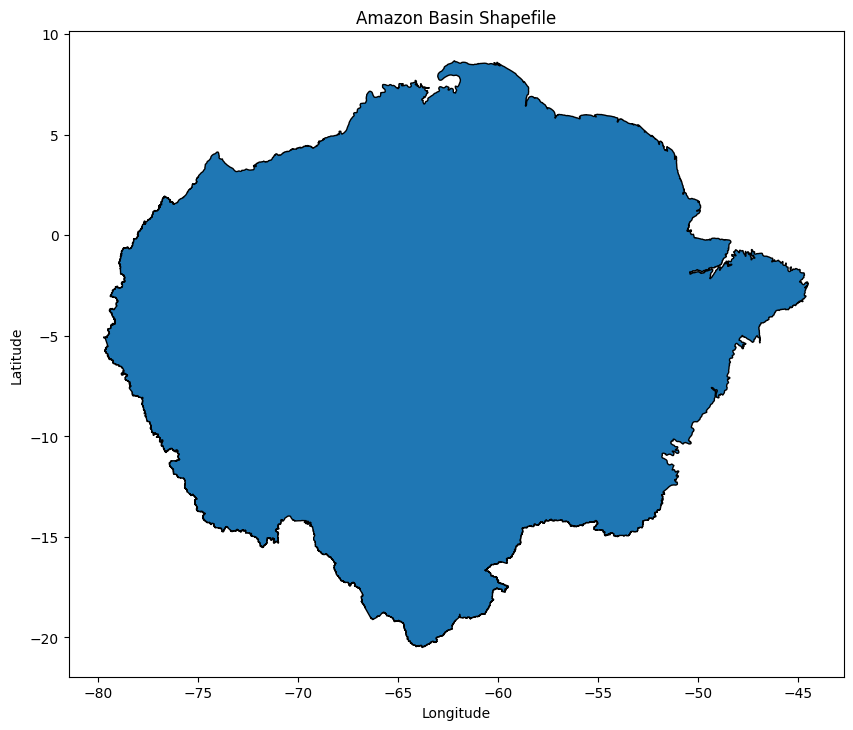

In [3]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
gdf.plot(figsize=(10, 10), edgecolor='black')
plt.title("Amazon Basin Shapefile")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**GEE**

In [4]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.1 MB/s eta 0:00:00


In [5]:
import ee

In [6]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='gee-ai-test1')

**Amazon outline-GEE**

In [7]:
import ee
import json

# Assume gdf contains the Amazon basin polygon (not just a bounding box)
amazon_geom = gdf.geometry.iloc[0]  # Extract shapely Polygon
geojson_dict = json.loads(gdf.to_json())['features'][0]['geometry']
amazon_ee_geom = ee.Geometry(geojson_dict)

In [8]:
from shapely.geometry import mapping
import ee

# Get the full Amazon basin shape and convert to a clean bounding polygon
bbox = gdf.geometry.unary_union.envelope  # or gdf.unary_union if you're confident in the union
amazon_ee_geom = ee.Geometry(mapping(bbox))

<ipython-input-8-6ede5ff6c8cf>:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bbox = gdf.geometry.unary_union.envelope  # or gdf.unary_union if you're confident in the union


**Brazil nut**

In [9]:
import pandas as pd

In [10]:
import ee
import geemap
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Point
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
file_path = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/Points_digitized.csv'  # Ensure this file is uploaded to your Colab environment
data = pd.read_csv(file_path)

In [12]:
data.head()

,Id,type,POINT_X,POINT_Y
0,0,large platform mounds,-64.357915,-15.000864
1,1,large platform mounds,-64.774797,-14.983732
2,2,large platform mounds,-64.286531,-15.294966
3,3,large platform mounds,-64.343638,-15.172186
4,4,large platform mounds,-64.797639,-15.166475


In [13]:
brazil_df = data[data['type'] == 'brazil nuts']

print(brazil_df.head())

    Id         type    POINT_X    POINT_Y
86  86  brazil nuts -53.116097 -14.193188
87  87  brazil nuts -52.889382 -10.864417
88  88  brazil nuts -54.825311 -11.703891
89  89  brazil nuts -55.961742 -11.235613
90  90  brazil nuts -55.910345 -11.229903


**Visualise brazil nuts**

In [14]:
# Create Point geometries
geometry = [Point(xy) for xy in zip(brazil_df.POINT_X, brazil_df.POINT_Y)]
brazil_gdf = gpd.GeoDataFrame(brazil_df, geometry=geometry)

# Set coordinate reference system to match the shapefile (likely WGS84)
brazil_gdf.set_crs("EPSG:4326", inplace=True)


,Id,type,POINT_X,POINT_Y,geometry
86,86,brazil nuts,-53.116097,-14.193188,POINT (-53.1161 -14.19319)
87,87,brazil nuts,-52.889382,-10.864417,POINT (-52.88938 -10.86442)
88,88,brazil nuts,-54.825311,-11.703891,POINT (-54.82531 -11.70389)
89,89,brazil nuts,-55.961742,-11.235613,POINT (-55.96174 -11.23561)
90,90,brazil nuts,-55.910345,-11.229903,POINT (-55.91034 -11.2299)
...,...,...,...,...,...
543,543,brazil nuts,-57.879175,-7.932255,POINT (-57.87918 -7.93226)
544,544,brazil nuts,-57.931523,-7.532506,POINT (-57.93152 -7.53251)
545,545,brazil nuts,-55.229248,5.471725,POINT (-55.22925 5.47172)
546,546,brazil nuts,-52.935448,5.347993,POINT (-52.93545 5.34799)


In [15]:
gdf = gpd.read_file(shapefile_path)
gdf = gdf.to_crs("EPSG:4326")  # Ensure CRS match


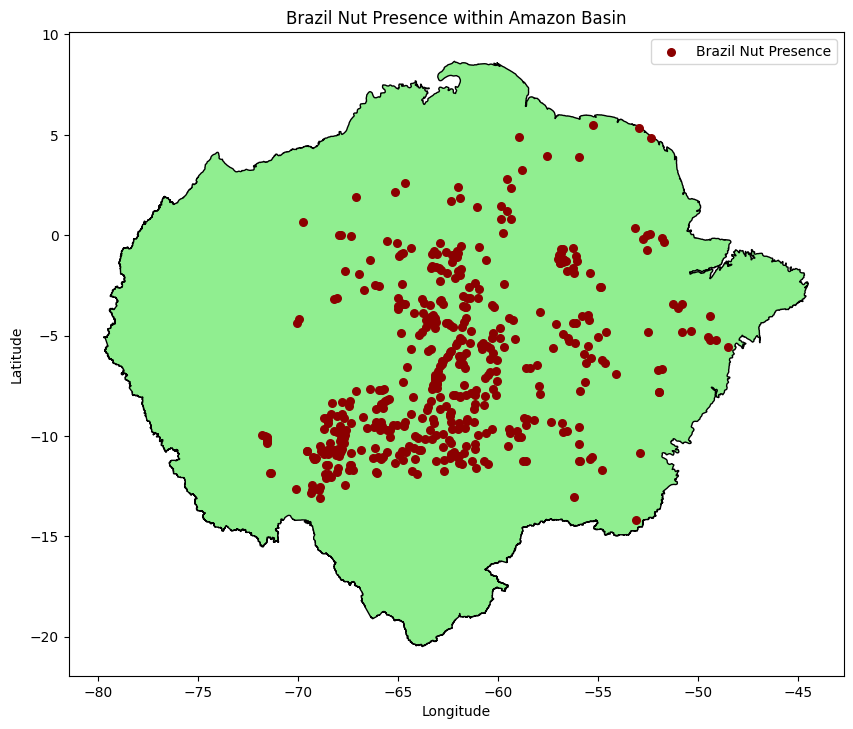

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgreen', edgecolor='black')
brazil_gdf.plot(ax=ax, color='darkred', markersize=30, label='Brazil Nut Presence')

plt.title("Brazil Nut Presence within Amazon Basin")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


**Presence-absence data**

In [17]:
brazil_gdf['label'] = 1


In [18]:
import random
from shapely.geometry import Point
import numpy as np

# Create a bounding box for the Amazon shapefile
amazon_polygon = gdf.unary_union  # unified Amazon polygon

# Generate random points within bounding box and test if inside the polygon
absence_points = []
count = 0
minx, miny, maxx, maxy = amazon_polygon.bounds

while count < 500:
    random_point = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
    if amazon_polygon.contains(random_point):
        absence_points.append(random_point)
        count += 1

# Create GeoDataFrame for absence
absence_gdf = gpd.GeoDataFrame({'label': [0]*500}, geometry=absence_points, crs="EPSG:4326")


<ipython-input-18-52ef2660ffb6>:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  amazon_polygon = gdf.unary_union  # unified Amazon polygon


In [19]:
combined_gdf = pd.concat([brazil_gdf[['geometry', 'label']], absence_gdf], ignore_index=True)


In [20]:
combined_gdf['lon'] = combined_gdf.geometry.x
combined_gdf['lat'] = combined_gdf.geometry.y


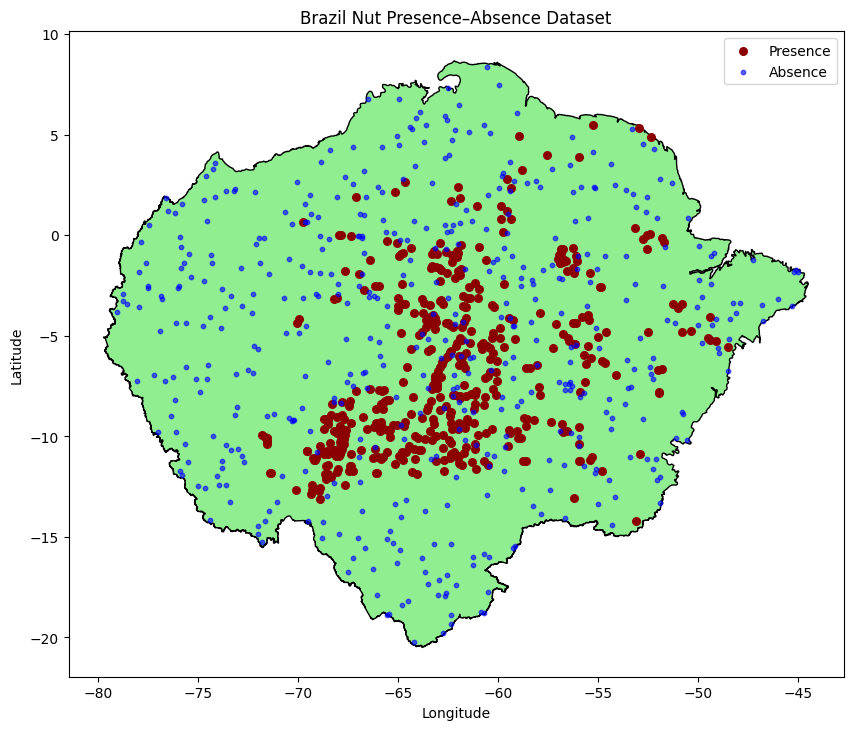

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgreen', edgecolor='black')
combined_gdf[combined_gdf.label == 1].plot(ax=ax, color='darkred', markersize=30, label='Presence')
combined_gdf[combined_gdf.label == 0].plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='Absence')

plt.title("Brazil Nut Presence–Absence Dataset")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


In [ ]:
path='/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM'

In [22]:
combined_gdf.head()

,geometry,label,lon,lat
0,POINT (-53.1161 -14.19319),1,-53.116097,-14.193188
1,POINT (-52.88938 -10.86442),1,-52.889382,-10.864417
2,POINT (-54.82531 -11.70389),1,-54.825311,-11.703891
3,POINT (-55.96174 -11.23561),1,-55.961742,-11.235613
4,POINT (-55.91034 -11.2299),1,-55.910345,-11.229903


In [ ]:
# Define output path
output_path = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/brazil_nut_presence_absence.csv'

# Save to CSV (including lat/lon and label)
combined_gdf[['lon', 'lat', 'label']].to_csv(output_path, index=False)

print("✅ Saved to:", output_path)

✅ Saved to: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/brazil_nut_presence_absence.csv


**Bioclim**

In [23]:
# Step 3: Load environmental predictors from GEE
bio_dataset = ee.Image("WORLDCLIM/V1/BIO")
bio_vars = ['bio02', 'bio03', 'bio04','bio05','bio07', 'bio13', 'bio15','bio18','bio19']
bio_imgs = [bio_dataset.select(b).multiply(0.1 if 'bio' in b and int(b[-2:]) <= 11 else 1) for b in bio_vars]


**Topography**

In [24]:
import geopandas as gpd
import ee
from shapely.geometry import mapping

# Load FABDEM ImageCollection
fabdem_ic = ee.ImageCollection("projects/sat-io/open-datasets/FABDEM")

# Filter tiles overlapping the polygon and mosaic them into one image
fabdem_mosaic = fabdem_ic.filterBounds(amazon_ee_geom).mosaic()

# Clip the mosaicked FABDEM image by the polygon
fabdem_clipped = fabdem_mosaic.clip(amazon_ee_geom)

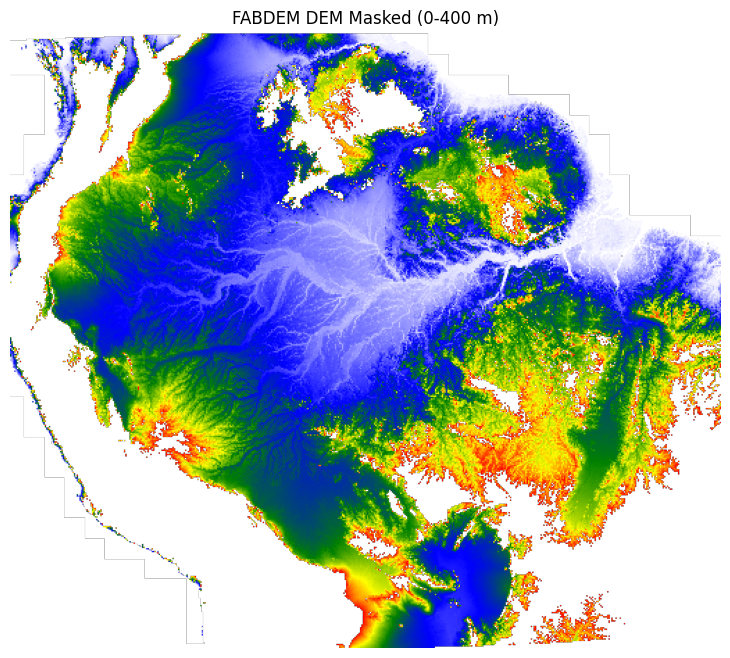

In [25]:
import ee
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

#ee.Initialize()

# Assuming fabdem_clipped and amazon_ee_geom are defined

# Mask values outside 0 to 400
elevation = fabdem_clipped.updateMask(fabdem_clipped.gte(0).And(fabdem_clipped.lte(400)))

# Visualization parameters (only values 0-400)
vis_params = {
    'min': 0,
    'max': 400,
    'palette': ['white', 'blue', 'green', 'yellow', 'red']
}

# Get thumbnail URL for masked image
thumb_url = elevation.getThumbURL({
    'min': vis_params['min'],
    'max': vis_params['max'],
    'palette': vis_params['palette'],
    'region': amazon_ee_geom,
    'dimensions': 512
})

# Fetch and display
response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title("FABDEM DEM Masked (0-400 m)")
plt.axis('off')
plt.show()

In [26]:
# Rename elevation band for clarity
elevation = elevation.rename("elevation")



In [27]:
# Calculate the slope from the DEM
slope = ee.Terrain.slope(fabdem_clipped)

In [28]:
# Hillshade

# Calculate hillshade from the DEM
hillshade = ee.Terrain.hillshade(fabdem_clipped)


In [29]:
aspect = ee.Terrain.aspect(fabdem_clipped)



In [30]:
rivdis='/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/distance_longest_river.tif'

In [31]:
# Step 3: Derive terrain variables from FABDEM
elevation = fabdem_clipped.updateMask(fabdem_clipped.gte(0).And(fabdem_clipped.lte(400))).rename("elevation")
slope = ee.Terrain.slope(fabdem_clipped).rename("slope")
aspect = ee.Terrain.aspect(fabdem_clipped).rename("aspect")
hillshade = ee.Terrain.hillshade(fabdem_clipped).rename("hillshade")

# Step 4: Stack all predictors into a single image
predictor_stack = ee.Image.cat(bio_imgs + [elevation, slope, aspect, hillshade])

In [32]:
predictor_stack

In [33]:
# Load pH (topsoil, b0) and clip
ph_raw = ee.Image('OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02')
ph_b0 = ph_raw.select('b0').clip(amazon_ee_geom).rename('soil_ph_b0')

# Load soil texture class (topsoil, b0) and clip
txt_raw = ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02')
txt_b0 = txt_raw.select('b0').clip(amazon_ee_geom).rename('soil_texture_b0')

# Add to predictor stack
predictor_stack = predictor_stack.addBands([ph_b0, txt_b0])


In [34]:
predictor_stack

In [35]:
# Load GFPLAIN250 (Geomorphological Units)
gfplain_mosaic = ee.ImageCollection("projects/sat-io/open-datasets/GFPLAIN250").filterBounds(amazon_ee_geom).mosaic()
gfplain_clipped = gfplain_mosaic.clip(amazon_ee_geom).rename("gfplain")


In [36]:
# Combine all into a single predictor stack
predictor_stack = ee.Image.cat(
    bio_imgs + [
        elevation, slope, aspect, hillshade,
        ph_b0, txt_b0, gfplain_clipped
    ]
)

In [37]:
predictor_stack

**Predictors**

In [38]:
# Convert GeoDataFrame to EE FeatureCollection
def gdf_to_fc(gdf, lat_col='lat', lon_col='lon'):
    features = []
    for i, row in gdf.iterrows():
        geom = ee.Geometry.Point([row[lon_col], row[lat_col]])
        feat = ee.Feature(geom, row.drop(['geometry']).to_dict())
        features.append(feat)
    return ee.FeatureCollection(features)


ee_points = gdf_to_fc(combined_gdf)

In [39]:
# Sample predictor stack at your labelled points
sampled_points = predictor_stack.sampleRegions(
    collection=ee_points,
    properties=['label'],
    scale=250,
    geometries=True
)


In [ ]:
task = ee.batch.Export.table.toDrive(
    collection=sampled_points,
    description='BrazilNut_PredictorSamples',
    fileFormat='CSV'
)
task.start()


In [40]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

In [41]:
# Load sampled data
df = pd.read_csv('/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/BrazilNut_PredictorSamples.csv')


In [42]:
df.head()

,system:index,aspect,bio02,bio03,bio04,bio05,bio07,bio13,bio15,bio18,bio19,elevation,gfplain,hillshade,label,slope,soil_ph_b0,soil_texture_b0,.geo
0,5_0,331.003700,14.3,6.9,75.1,35.4,20.5,315.0,75.0,474.0,56.0,278.72748,0,180,1,0.014696,44,6,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,6_0,331.003700,14.4,7.0,72.7,35.3,20.4,321.0,75.0,481.0,59.0,283.72750,0,180,1,0.014696,49,9,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,7_0,41.663690,14.0,7.0,64.0,35.6,19.9,347.0,71.0,313.0,74.0,241.64624,0,180,1,0.029958,47,6,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,17_0,308.134400,12.4,6.7,50.6,34.2,18.5,357.0,71.0,265.0,101.0,193.78609,0,180,1,0.048840,41,6,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,39_0,27.367533,11.4,6.9,49.7,33.5,16.5,346.0,71.0,264.0,109.0,99.62703,0,180,1,0.031309,44,6,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [43]:
# Drop any rows with missing values
df = df.dropna()

              precision    recall  f1-score   support

           0       1.00      0.67      0.80        18
           1       0.84      1.00      0.91        32

    accuracy                           0.88        50
   macro avg       0.92      0.83      0.86        50
weighted avg       0.90      0.88      0.87        50

ROC AUC Score: 0.9175347222222223


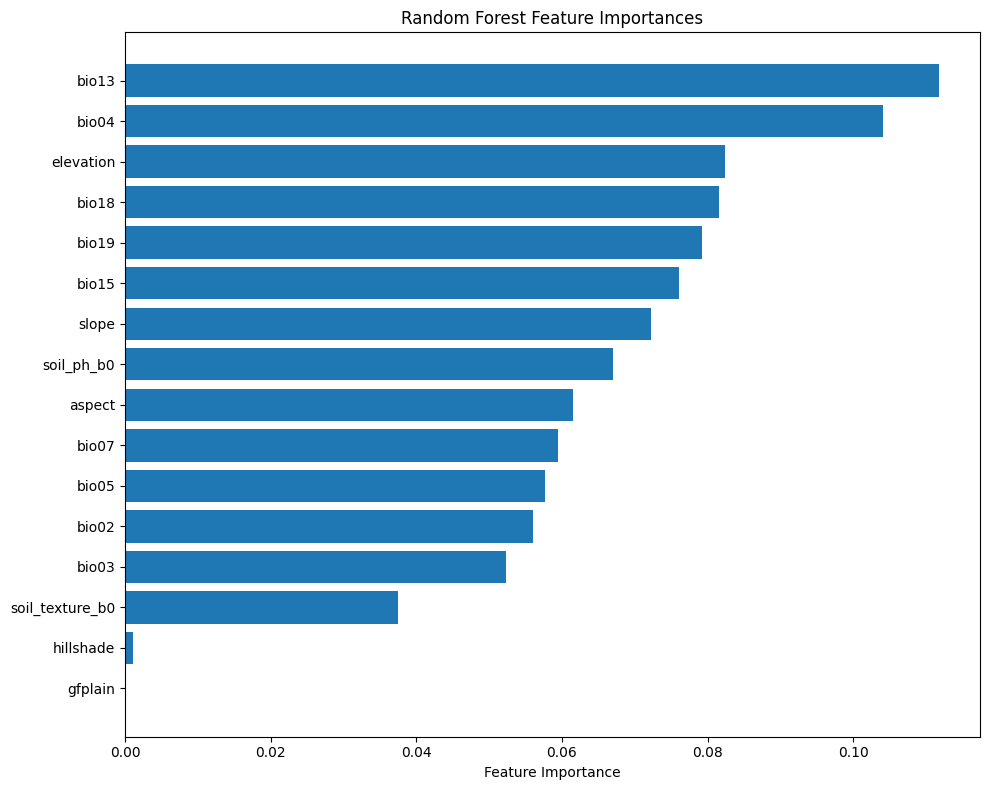

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# Drop non-predictor columns including geometry
X = df.drop(columns=['system:index', 'label', '.geo'])  # Add 'geometry' too if it exists
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Feature Importance Plot
importances = clf.feature_importances_
feature_names = X.columns
sorted_idx = importances.argsort()

plt.figure(figsize=(10, 8))
plt.barh(range(len(importances)), importances[sorted_idx], align='center')
plt.yticks(range(len(importances)), feature_names[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


In [45]:
import joblib

# Updated path to save the model
model_path = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/rf_model.pkl'

# Save the trained model
joblib.dump(clf, model_path)

print(f"✅ Random Forest model saved to: {model_path}")


✅ Random Forest model saved to: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/rf_model.pkl


In [46]:
clf = joblib.load('/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/rf_model.pkl')


**Build actual map**

In [47]:
!pip install rasterio

In [48]:
tile_folder = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM'

In [49]:
# See exactly what files exist
!ls "/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM"


BrazilNut_PredictorSamples.csv
brazil_nut_presence_absence.csv
brazilNut_sdm1.ipynb
brazilnut_suitability_map1.tif
predictor_stack_gee-0000000000-0000000000.tif
predictor_stack_gee-0000000000-0000008192.tif
predictor_stack_gee-0000008192-0000000000.tif
predictor_stack_gee-0000008192-0000008192.tif
rf_model.pkl


In [5]:
import rasterio
from rasterio.merge import merge
import glob
import os

In [50]:
import os
import glob
import joblib
import rasterio
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Load your trained model
model_path = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/rf_model.pkl'
clf = joblib.load(model_path)

# Set folder with predictor tiles
tile_folder = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM'
tile_paths = sorted(glob.glob(os.path.join(tile_folder, 'predictor_stack_gee-*-*.tif')))

# Output folder (same location)
output_folder = tile_folder  # will save into AmazonSDM
print(f"🗂️ Found {len(tile_paths)} predictor tiles.")

# Process tile by tile
for tile_path in tile_paths:
    with rasterio.open(tile_path) as src:
        data = src.read()  # shape: (bands, rows, cols)
        meta = src.meta.copy()

    n_bands, n_rows, n_cols = data.shape
    flat_data = data.reshape(n_bands, -1).T

    # Predict only on valid (non-NaN) pixels
    valid_mask = ~np.any(np.isnan(flat_data), axis=1)
    preds = np.zeros(flat_data.shape[0], dtype='float32')
    preds[valid_mask] = clf.predict_proba(flat_data[valid_mask])[:, 1]  # probability of class 1 (suitability)

    # Reshape back to 2D
    prediction = preds.reshape(n_rows, n_cols).astype('float32')

    # Update metadata
    meta.update(count=1, dtype='float32')

    # Save as new file
    tile_name = os.path.basename(tile_path).replace('.tif', '_SDM_BrazilNut.tif')
    output_path = os.path.join(output_folder, tile_name)

    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(prediction, 1)

    print(f"✅ Saved: {output_path}")


🗂️ Found 4 predictor tiles.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000000000-0000000000_SDM_BrazilNut.tif


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000000000-0000008192_SDM_BrazilNut.tif


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000008192-0000000000_SDM_BrazilNut.tif


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000008192-0000008192_SDM_BrazilNut.tif


binary

In [51]:
# Output folder
output_folder = tile_folder
print(f"🧩 Processing {len(tile_paths)} tiles...")

for tile_path in tile_paths:
    with rasterio.open(tile_path) as src:
        data = src.read()
        meta = src.meta.copy()

    n_bands, n_rows, n_cols = data.shape
    flat_data = data.reshape(n_bands, -1).T

    # Predict only valid pixels
    valid_mask = ~np.any(np.isnan(flat_data), axis=1)
    probs = np.zeros(flat_data.shape[0], dtype='float32')
    probs[valid_mask] = clf.predict_proba(flat_data[valid_mask])[:, 1]  # Prob(class=1)

    # Binary thresholding at 0.5
    binary = (probs >= 0.5).astype('uint8')  # 1 for suitable, 0 for unsuitable

    # Reshape both to 2D
    prob_map = probs.reshape(n_rows, n_cols)
    binary_map = binary.reshape(n_rows, n_cols)

    # Save continuous suitability raster
    meta.update(count=1, dtype='float32')
    out_cont_path = os.path.join(output_folder,
        os.path.basename(tile_path).replace('.tif', '_SDM_Prob.tif'))

    with rasterio.open(out_cont_path, 'w', **meta) as dst:
        dst.write(prob_map, 1)

    # Save binary raster
    meta.update(dtype='uint8')
    out_bin_path = os.path.join(output_folder,
        os.path.basename(tile_path).replace('.tif', '_SDM_Binary.tif'))

    with rasterio.open(out_bin_path, 'w', **meta) as dst:
        dst.write(binary_map, 1)

    print(f"✅ Saved: {out_cont_path}")
    print(f"✅ Saved: {out_bin_path}")

🧩 Processing 4 tiles...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000000000-0000000000_SDM_Prob.tif
✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000000000-0000000000_SDM_Binary.tif


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000000000-0000008192_SDM_Prob.tif
✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000000000-0000008192_SDM_Binary.tif


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000008192-0000000000_SDM_Prob.tif
✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000008192-0000000000_SDM_Binary.tif


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000008192-0000008192_SDM_Prob.tif
✅ Saved: /content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/predictor_stack_gee-0000008192-0000008192_SDM_Binary.tif


In [52]:
import rasterio
from rasterio.merge import merge
import glob
import os

# Path to folder with your binary tiles
tile_folder = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM'

# Match all binary SDM tiles
binary_tile_paths = sorted(glob.glob(os.path.join(tile_folder, '*_SDM_Binary.tif')))
print(f"🧩 Found {len(binary_tile_paths)} binary tiles to merge.")


🧩 Found 4 binary tiles to merge.


In [54]:
import rasterio
from rasterio.merge import merge
import glob
import os
import numpy as np

# Define the folder with the SDM binary tiles
tile_folder = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM'

# Find all binary raster tiles
binary_tile_paths = sorted(glob.glob(os.path.join(tile_folder, '*_SDM_Binary.tif')))
print(f"🧩 Found {len(binary_tile_paths)} binary tiles.")

# Open all tiles
src_files = [rasterio.open(p) for p in binary_tile_paths]

# Merge tiles (using max so any 1 in overlapping areas is preserved)
mosaic, out_trans = merge(src_files, method='max')

# Prepare output metadata
out_meta = src_files[0].meta.copy()
out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "count": 1,
    "dtype": 'uint8'
})

# Output path for the merged raster
merged_path = os.path.join(tile_folder, 'BrazilNut_SDM_Binary_MERGED.tif')

# Save the merged raster
with rasterio.open(merged_path, 'w', **out_meta) as dest:
    dest.write(np.squeeze(mosaic).astype('uint8'), 1)

print(f"✅ Merged binary SDM raster saved at:\n{merged_path}")


🧩 Found 4 binary tiles.
✅ Merged binary SDM raster saved at:
/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/BrazilNut_SDM_Binary_MERGED.tif


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


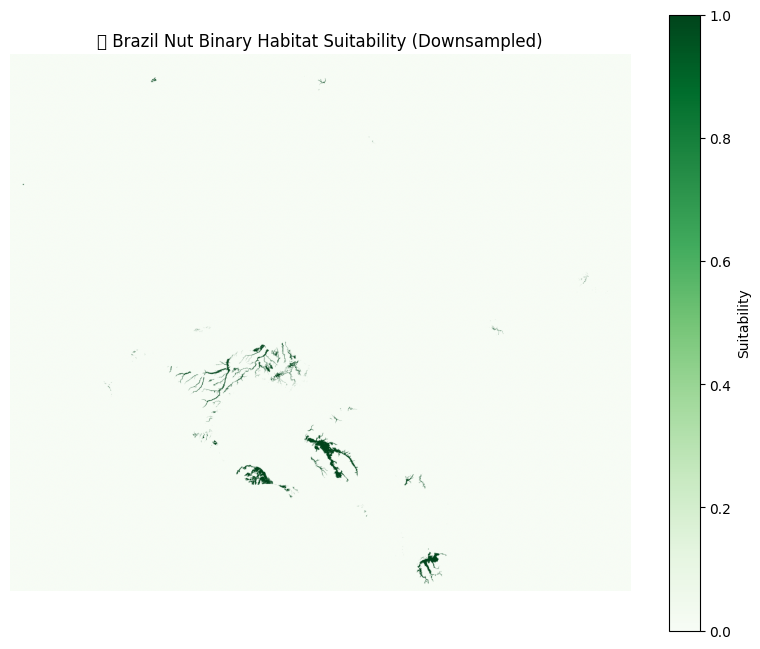

In [1]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

# Path to the large raster
merged_path = '/content/drive/MyDrive/AI_Amazon_Fire/AmazonRaster/AmazonSDM/BrazilNut_SDM_Binary_MERGED.tif'

# Open with downsampling
with rasterio.open(merged_path) as src:
    # Read a downsampled version (e.g. 4x smaller in each dimension)
    data = src.read(
        1,
        out_shape=(
            int(src.height // 4),
            int(src.width // 4)
        ),
        resampling=Resampling.nearest
    )

# Plot the downsampled image
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='Greens', vmin=0, vmax=1)
plt.title("🌱 Brazil Nut Binary Habitat Suitability (Downsampled)")
plt.axis('off')
plt.colorbar(label='Suitability')
plt.show()
